In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Environment Check ---")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Statsmodels version: {sm.__version__}")
print(f"Seaborn version: {sns.__version__}")
print("\nAll libraries imported successfully!")


--- Environment Check ---
Pandas version: 3.0.5
NumPy version: 2.4.6
Statsmodels version: 0.14.6
Seaborn version: 0.13.2

All libraries imported successfully!


In [3]:
# Filter out non-positive prices and quantities
df_clean = df[(df['Price'] > 0) & (df['Quantity'] > 0)].copy()

print(f"Original rows: {len(df)} | Clean rows: {len(df_clean)}")

NameError: name 'df' is not defined

In [4]:
import pandas as pd
import numpy as np

# Load the raw dataset saved during Phase 1
df = pd.read_csv("retail _price.csv")

# Ensure Date column is parsed as datetime
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset loaded successfully! Total rows:", len(df))

FileNotFoundError: [Errno 2] No such file or directory: 'retail _price.csv'

In [8]:
import pandas as pd
import numpy as np

# Loading the raw dataset saved during Phase 1
df = pd.read_csv("retail_price.csv")

# Ensuring Date column is parsed as datetime
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset loaded successfully! Total rows:", len(df))

KeyError: 'Date'

In [9]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("retail_price.csv")

# Printing all actual column names in the file
print("Your actual columns:", df.columns.tolist())

# Auto-fix column name if it's lowercase 'date'
df.columns = df.columns.str.strip()  # remove extra spaces
if 'date' in df.columns:
    df.rename(columns={'date': 'Date'}, inplace=True)

# Parse Date if column exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    print("Date column processed successfully!")
else:
    print("\nNo 'Date' column found. Please locate your date column from the list above.")

Your actual columns: ['product_id', 'product_category_name', 'month_year', 'qty', 'total_price', 'freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price']

No 'Date' column found. Please locate your date column from the list above.


In [10]:
import pandas as pd
import numpy as np

# Loading dataset
df = pd.read_csv("retail_price.csv")

# Print column names
print("Columns in your file:")
print(df.columns.tolist())

Columns in your file:
['product_id', 'product_category_name', 'month_year', 'qty', 'total_price', 'freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price']


In [11]:
import pandas as pd
import numpy as np

# Loading the raw dataset
df = pd.read_csv("retail_price.csv") 

# 1. Filtering out non-positive price or quantity values
df_clean = df[(df['unit_price'] > 0) & (df['qty'] > 0)].copy()

# 2. Renaming core columns to standard names for clarity
df_clean.rename(columns={
    'unit_price': 'Price',
    'qty': 'Quantity',
    'product_id': 'Product'
}, inplace=True)

# 3. Creating Log Transformations for Price Elasticity
df_clean['log_Price'] = np.log(df_clean['Price'])
df_clean['log_Quantity'] = np.log(df_clean['Quantity'])

# 4. Verifying shape and new columns
print(f"Data cleaned successfully! Total rows: {len(df_clean)}")
df_clean[['Product', 'Price', 'Quantity', 'log_Price', 'log_Quantity']].head()

Data cleaned successfully! Total rows: 676


,Product,Price,Quantity,log_Price,log_Quantity
0,bed1,45.95,1,3.827554,0.000000
1,bed1,45.95,3,3.827554,1.098612
2,bed1,45.95,6,3.827554,1.791759
3,bed1,45.95,4,3.827554,1.386294
4,bed1,45.95,2,3.827554,0.693147


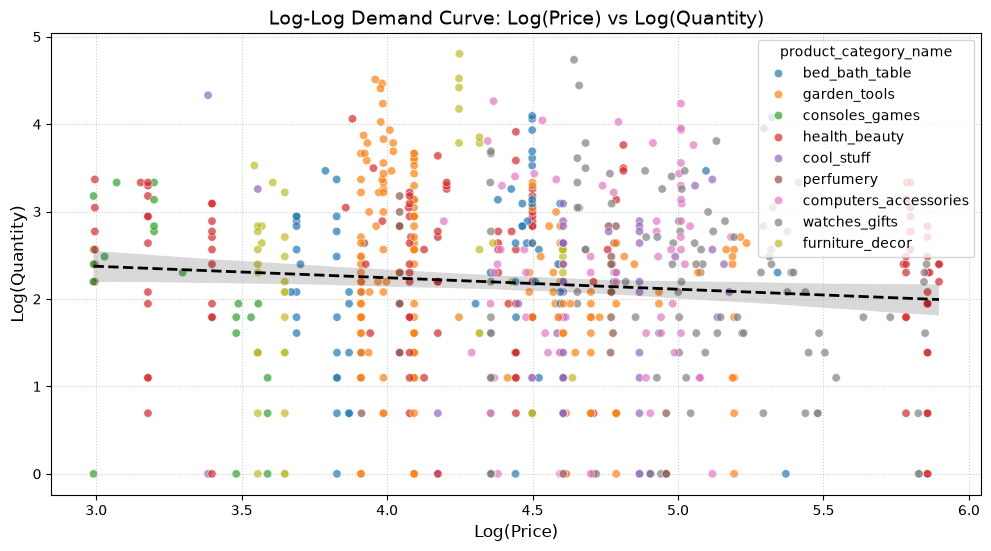

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Scatter plot of log_Price vs log_Quantity colored by product category
sns.scatterplot(
    data=df_clean, 
    x='log_Price', 
    y='log_Quantity', 
    hue='product_category_name', 
    alpha=0.7
)

# Overall trendline representing average price elasticity slope
sns.regplot(
    data=df_clean, 
    x='log_Price', 
    y='log_Quantity', 
    scatter=False, 
    color='black', 
    line_kws={'linestyle': '--', 'linewidth': 2}
)

plt.title("Log-Log Demand Curve: Log(Price) vs Log(Quantity)", fontsize=14)
plt.xlabel("Log(Price)", fontsize=12)
plt.ylabel("Log(Quantity)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [13]:
# Saving clean dataset for econometric modeling in Phase 3
df_clean.to_csv("price_elasticity_processed.csv", index=False)
print("Phase 2 Complete! Saved clean file as 'price_elasticity_processed.csv'")

Phase 2 Complete! Saved clean file as 'price_elasticity_processed.csv'


In [14]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Loading processed data from Phase 2
df = pd.read_csv("price_elasticity_processed.csv")

# Baseline Model: log_Quantity = beta_0 + beta_1 * log_Price
model_simple = smf.ols('log_Quantity ~ log_Price', data=df).fit()

# View statistical output
print("--- BASELINE MODEL SUMMARY ---")
print(model_simple.summary())

--- BASELINE MODEL SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:           log_Quantity   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     4.438
Date:                Sat, 15 Aug 2026   Prob (F-statistic):             0.0355
Time:                        19:23:56   Log-Likelihood:                -993.52
No. Observations:                 676   AIC:                             1991.
Df Residuals:                     674   BIC:                             2000.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.7681

In [15]:
# Creating log of freight price for control
df['log_freight'] = np.log(df['freight_price'] + 0.01)

# Fit Multiple Regression Model with control variables
formula_multi = 'log_Quantity ~ log_Price + log_freight + weekend + holiday + product_score'
model_multi = smf.ols(formula_multi, data=df).fit()

print("--- MULTIPLE REGRESSION MODEL SUMMARY ---")
print(model_multi.summary())

--- MULTIPLE REGRESSION MODEL SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:           log_Quantity   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     5.993
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           1.95e-05
Time:                        19:24:28   Log-Likelihood:                -980.95
No. Observations:                 676   AIC:                             1974.
Df Residuals:                     670   BIC:                             2001.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Inte

In [16]:
category_elasticities = []

# Looping through each product category to fit category-specific models
for category, group in df.groupby('product_category_name'):
    if len(group) >= 10:  # Ensure adequate sample size
        cat_model = smf.ols('log_Quantity ~ log_Price + weekend + holiday', data=group).fit()
        
        elasticity = cat_model.params['log_Price']
        p_val = cat_model.pvalues['log_Price']
        r_sq = cat_model.rsquared
        
        category_elasticities.append({
            'Category': category,
            'Elasticity (beta_1)': round(elasticity, 4),
            'P-Value': round(p_val, 4),
            'R-Squared': round(r_sq, 4),
            'Demand Sensitivity': 'Elastic' if elasticity < -1 else 'Inelastic'
        })

# Converting to DataFrame
df_elasticity = pd.DataFrame(category_elasticities)
df_elasticity.to_csv("category_elasticity_results.csv", index=False)
print("--- CATEGORY ELASTICITY RESULTS ---")
print(df_elasticity)

--- CATEGORY ELASTICITY RESULTS ---
                Category  Elasticity (beta_1)  P-Value  R-Squared  \
0         bed_bath_table               0.6422   0.0229     0.1493   
1  computers_accessories               0.3564   0.4964     0.0416   
2         consoles_games              -2.2492   0.0162     0.3630   
3             cool_stuff               0.1477   0.6741     0.0166   
4        furniture_decor               0.3154   0.4418     0.0723   
5           garden_tools              -0.8314   0.0000     0.1754   
6          health_beauty              -0.1429   0.0906     0.0348   
7              perfumery              -0.5891   0.1616     0.1794   
8          watches_gifts              -0.3465   0.1782     0.0392   

  Demand Sensitivity  
0          Inelastic  
1          Inelastic  
2            Elastic  
3          Inelastic  
4          Inelastic  
5          Inelastic  
6          Inelastic  
7          Inelastic  
8          Inelastic  


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the category elasticity results from Phase 3
df_cat = pd.read_csv("category_elasticity_results.csv")
df_proc = pd.read_csv("price_elasticity_processed.csv")

def simulate_revenue(category_name, price_change_pcts=np.linspace(-0.25, 0.25, 51)):
    # Extracting baseline price and quantity for the category
    cat_data = df_proc[df_proc['product_category_name'] == category_name]
    base_price = cat_data['Price'].mean()
    base_qty = cat_data['Quantity'].mean()
    
    # Getting elasticity coefficient (beta_1) from Phase 3
    beta_1 = df_cat.loc[df_cat['Category'] == category_name, 'Elasticity (beta_1)'].values[0]
    
    simulation_results = []
    
    for pct in price_change_pcts:
        new_price = base_price * (1 + pct)
        # Demand prediction: Q_new = Q_base * (P_new / P_base)^elasticity
        predicted_qty = base_qty * ((new_price / base_price) ** beta_1)
        predicted_revenue = new_price * predicted_qty
        
        simulation_results.append({
            'Category': category_name,
            'Price Change %': round(pct * 100, 1),
            'Simulated Price': round(new_price, 2),
            'Predicted Quantity': round(predicted_qty, 2),
            'Predicted Revenue': round(predicted_revenue, 2)
        })
        
    return pd.DataFrame(simulation_results)

In [18]:
all_simulations = []
optimization_summary = []

for category in df_cat['Category']:
    sim_df = simulate_revenue(category)
    all_simulations.append(sim_df)
    
    # Baseline revenue (0% price change)
    base_rev = sim_df.loc[sim_df['Price Change %'] == 0, 'Predicted Revenue'].values[0]
    base_price = sim_df.loc[sim_df['Price Change %'] == 0, 'Simulated Price'].values[0]
    
    # Optimal price point (Maximum Revenue)
    opt_row = sim_df.loc[sim_df['Predicted Revenue'].idxmax()]
    max_rev = opt_row['Predicted Revenue']
    opt_price = opt_row['Simulated Price']
    opt_pct = opt_row['Price Change %']
    
    rev_lift_pct = ((max_rev - base_rev) / base_rev) * 100
    
    optimization_summary.append({
        'Category': category,
        'Baseline Price': base_price,
        'Optimal Price (P*)': opt_price,
        'Recommended Price Change %': opt_pct,
        'Baseline Revenue': base_rev,
        'Max Revenue': max_rev,
        'Projected Revenue Lift %': round(rev_lift_pct, 2)
    })

df_summary = pd.DataFrame(optimization_summary)
df_summary.to_csv("price_optimization_summary.csv", index=False)

print("--- REVENUE OPTIMIZATION SUMMARY ---")
print(df_summary[['Category', 'Recommended Price Change %', 'Projected Revenue Lift %']])

--- REVENUE OPTIMIZATION SUMMARY ---
                Category  Recommended Price Change %  Projected Revenue Lift %
0         bed_bath_table                        25.0                     44.26
1  computers_accessories                        25.0                     35.35
2         consoles_games                       -25.0                     43.24
3             cool_stuff                        25.0                     29.19
4        furniture_decor                        25.0                     34.11
5           garden_tools                        25.0                      3.83
6          health_beauty                        25.0                     21.08
7              perfumery                        25.0                      9.60
8          watches_gifts                        25.0                     15.70


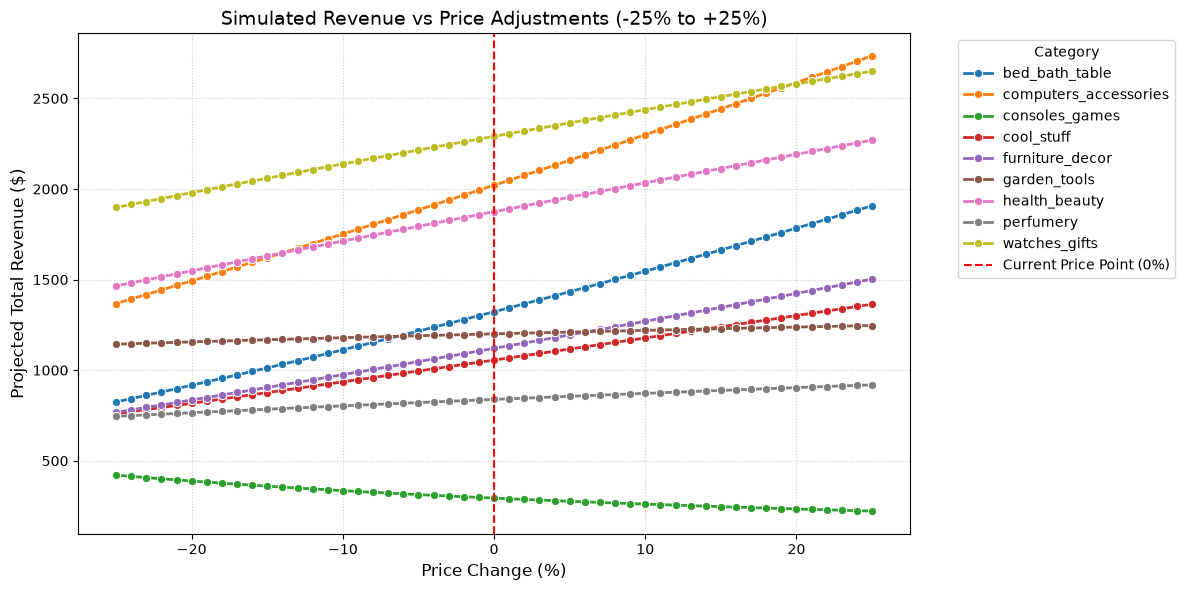

In [19]:
full_sim_df = pd.concat(all_simulations, ignore_index=True)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=full_sim_df, 
    x='Price Change %', 
    y='Predicted Revenue', 
    hue='Category', 
    marker='o', 
    linewidth=2
)

# Highlighting current baseline price point
plt.axvline(x=0, color='red', linestyle='--', label='Current Price Point (0%)')
plt.title("Simulated Revenue vs Price Adjustments (-25% to +25%)", fontsize=14)
plt.xlabel("Price Change (%)", fontsize=12)
plt.ylabel("Projected Total Revenue ($)", fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\AYAN KUMAR\AppData\Local\Temp\ipykernel_21188\3770130431.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\AYAN KUMAR\AppData\Local\Temp\ipykernel_21188\3770130431.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


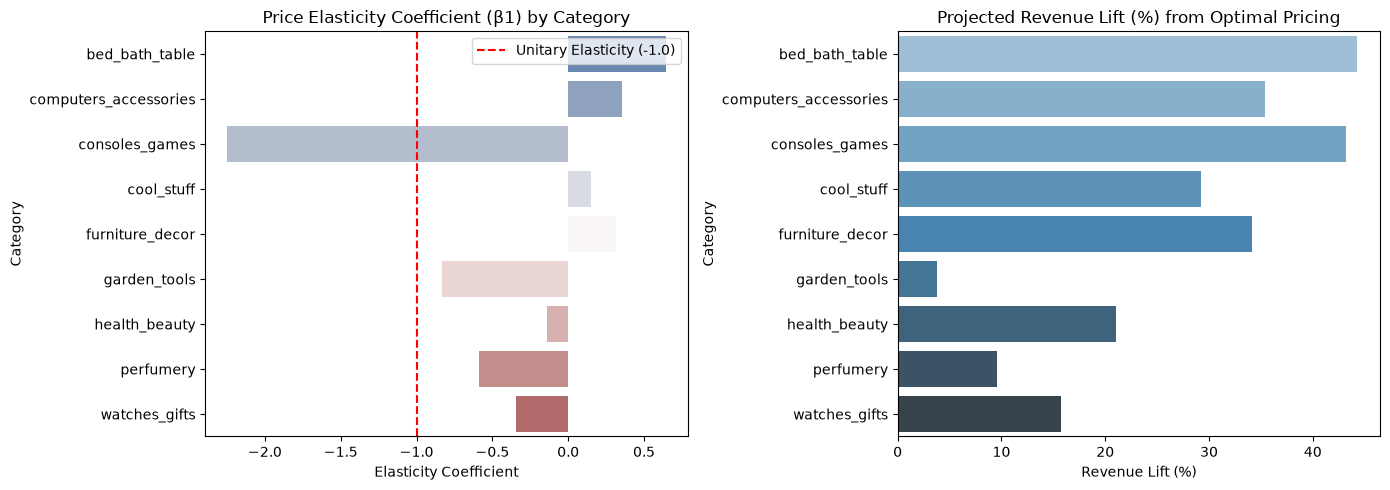

Dashboard visualization exported as 'executive_summary_dashboard.png'


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_summary = pd.read_csv("price_optimization_summary.csv")
df_cat = pd.read_csv("category_elasticity_results.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elasticity by Category
sns.barplot(
    data=df_cat, 
    x='Elasticity (beta_1)', 
    y='Category', 
    ax=axes[0], 
    palette='vlag'
)
axes[0].axvline(-1.0, color='red', linestyle='--', label='Unitary Elasticity (-1.0)')
axes[0].set_title("Price Elasticity Coefficient (β1) by Category", fontsize=12)
axes[0].set_xlabel("Elasticity Coefficient")
axes[0].legend()

# Plot 2: Projected Revenue Lift (%) by Category
sns.barplot(
    data=df_summary, 
    x='Projected Revenue Lift %', 
    y='Category', 
    ax=axes[1], 
    palette='Blues_d'
)
axes[1].set_title("Projected Revenue Lift (%) from Optimal Pricing", fontsize=12)
axes[1].set_xlabel("Revenue Lift (%)")

plt.tight_layout()
plt.savefig("executive_summary_dashboard.png", dpi=300)
plt.show()
print("Dashboard visualization exported as 'executive_summary_dashboard.png'")

In [21]:
print("=========================================================")
print("          EXECUTIVE PRICING & REVENUE BRIEF              ")
print("=========================================================\n")

for idx, row in df_summary.iterrows():
    cat = row['Category']
    rec_change = row['Recommended Price Change %']
    lift = row['Projected Revenue Lift %']
    base_p = row['Baseline Price']
    opt_p = row['Optimal Price (P*)']
    
    action = "Increase" if rec_change > 0 else "Decrease" if rec_change < 0 else "Maintain"
    
    print(f"Product Category: {cat}")
    print(f"  • Strategy: {action} price by {abs(rec_change)}%")
    print(f"  • Price Shift: ${base_p:.2f} ➔ ${opt_p:.2f}")
    print(f"  • Expected Impact: +{lift:.2f}% Revenue Lift")
    print("-" * 57)

          EXECUTIVE PRICING & REVENUE BRIEF              

Product Category: bed_bath_table
  • Strategy: Increase price by 25.0%
  • Price Shift: $78.63 ➔ $98.29
  • Expected Impact: +44.26% Revenue Lift
---------------------------------------------------------
Product Category: computers_accessories
  • Strategy: Increase price by 25.0%
  • Price Shift: $119.48 ➔ $149.35
  • Expected Impact: +35.35% Revenue Lift
---------------------------------------------------------
Product Category: consoles_games
  • Strategy: Decrease price by 25.0%
  • Price Shift: $27.03 ➔ $20.28
  • Expected Impact: +43.24% Revenue Lift
---------------------------------------------------------
Product Category: cool_stuff
  • Strategy: Increase price by 25.0%
  • Price Shift: $107.86 ➔ $134.82
  • Expected Impact: +29.19% Revenue Lift
---------------------------------------------------------
Product Category: furniture_decor
  • Strategy: Increase price by 25.0%
  • Price Shift: $60.15 ➔ $75.19
  • Expected 